<font color = green >

## Home Task
</font>

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
import h5py
import os
#cwd= os.getcwd()
#path = os.path.join(cwd,'data')
path = "/content"

<font color = green>

### Brest Cancer Dataset

</font>



In [ ]:
# https://scikit-learn.org/stable/datasets/index.html#breast-cancer-dataset
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y= True)
print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)

X.shape=  (569, 30)
y.shape=  (569,)


In [ ]:
# YOUR_CODE.  Preproces data, train classifier and evaluate the perfromance on train and test sets
# START_CODE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 8, stratify = y)
clf= MLPClassifier(verbose = True, random_state = 8, alpha = 20)
clf.fit(X_train, y_train)
y_pred_train = clf.predict(X_train)
y_pred = clf.predict(X_test)
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred)
print("train accuracy= {:.3%}".format(acc_train))
print("test accuracy= {:.3%}".format(acc_test))
# END_CODE


Iteration 1, loss = 25.86329381
Iteration 2, loss = 25.64396937
Iteration 3, loss = 18.87753562
Iteration 4, loss = 11.86287535
Iteration 5, loss = 14.80921473
Iteration 6, loss = 10.63042900
Iteration 7, loss = 8.14540145
Iteration 8, loss = 10.35945439
Iteration 9, loss = 5.93386559
Iteration 10, loss = 6.11805214
Iteration 11, loss = 5.84064067
Iteration 12, loss = 3.80134265
Iteration 13, loss = 5.35184950
Iteration 14, loss = 3.63198655
Iteration 15, loss = 3.48292900
Iteration 16, loss = 3.50295505
Iteration 17, loss = 2.90526073
Iteration 18, loss = 3.00462554
Iteration 19, loss = 2.75600972
Iteration 20, loss = 2.67697956
Iteration 21, loss = 2.60956604
Iteration 22, loss = 2.43985533
Iteration 23, loss = 2.52692040
Iteration 24, loss = 2.27909813
Iteration 25, loss = 2.29829203
Iteration 26, loss = 2.18056174
Iteration 27, loss = 2.16303610
Iteration 28, loss = 2.09761916
Iteration 29, loss = 2.02239936
Iteration 30, loss = 2.01967502
Iteration 31, loss = 1.94758065
Iteration 

<font color = green>

##  Signs dataset

</font>



In [ ]:
# signs data set (fingers)
def load_dataset():
    fn =  os.path.join(path , 'train_signs.h5')
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn =  os.path.join(path , 'test_signs.h5')
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes

    y_train = y_train.reshape((1, y_train.shape[0]))
    y_test = y_test.reshape((1, y_test.shape[0]))

    return X_train, y_train, X_test, y_test, classes


In [ ]:
X_train, y_train, X_test, y_test, classes = load_dataset()
y_train = y_train.ravel()
y_test = y_test.ravel()
print ('X_train.shape=', X_train.shape)
print ('X_test.shape=', X_test.shape)
print ('y_train.shape=', y_train.shape)
print ('y_test.shape=', y_test.shape)

X_train.shape= (1080, 64, 64, 3)
X_test.shape= (120, 64, 64, 3)
y_train.shape= (1080,)
y_test.shape= (120,)


In [ ]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_rows*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            plt.imshow(X[indices[index]])
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

    plt.tight_layout(h_pad=1)


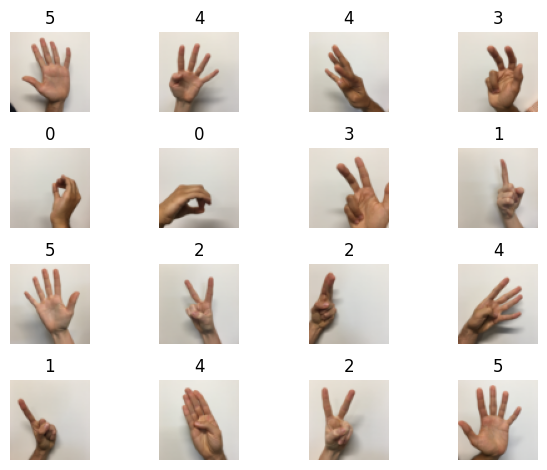

In [ ]:
plt.figure()

display_samples_in_grid(X_train, n_rows=4, y= y_train)

In [ ]:
#plt.gcf().canvas.set_window_title('Train set')

In [ ]:
# Not in use
def convert_to_one_hot(Y, C):
    Y = np.eye(C)[Y.reshape(-1)]
    return Y

In [ ]:
# YOUR_CODE.  Preproces data
# START_CODE
X_train_scaled = X_train.reshape(X_train.shape[0], -1)/255.
X_test_scaled = X_test.reshape(X_test.shape[0], -1)/255.
# END_CODE

print ("number of training examples = " + str(X_train_scaled.shape[1]))
print ("number of test examples = " + str(X_test_scaled.shape[1]))
print ("X_train_scaled shape: " + str(X_train_scaled.shape))

print ("X_test_scaled shape: " + str(X_test_scaled.shape))

number of training examples = 12288
number of test examples = 12288
X_train_scaled shape: (1080, 12288)
X_test_scaled shape: (120, 12288)


### Expected result

```
number of training examples = 12288
number of test examples = 12288
X_train_scaled shape: (1080, 12288)
X_test_scaled shape: (120, 12288)
```

In [ ]:
# YOUR_CODE.  Train classifier and evaluate the perfromance on train and test sets
# START_CODE
clf = MLPClassifier(verbose = True, hidden_layer_sizes=(128, 64), alpha=0.0001, activation='relu', solver='adam', max_iter=1000, random_state=8 )
clf.fit(X_train_scaled, y_train)
test_pred = clf.predict(X_test_scaled)
train_pred = clf.predict(X_train_scaled)
acc_test = accuracy_score(test_pred, y_test)
acc_train = accuracy_score(train_pred, y_train)
print("train accuracy= {:.3%}".format(acc_train))
print("test accuracy= {:.3%}".format(acc_test))
# END_CODE

Iteration 1, loss = 6.82312888
Iteration 2, loss = 4.23463735
Iteration 3, loss = 2.55794340
Iteration 4, loss = 2.28779083
Iteration 5, loss = 2.10864100
Iteration 6, loss = 1.79807170
Iteration 7, loss = 1.75998671
Iteration 8, loss = 1.68612841
Iteration 9, loss = 1.64441626
Iteration 10, loss = 1.54075377
Iteration 11, loss = 1.50651391
Iteration 12, loss = 1.47333136
Iteration 13, loss = 1.44490545
Iteration 14, loss = 1.44703643
Iteration 15, loss = 1.38428124
Iteration 16, loss = 1.38244170
Iteration 17, loss = 1.33028575
Iteration 18, loss = 1.35783020
Iteration 19, loss = 1.33624711
Iteration 20, loss = 1.31026967
Iteration 21, loss = 1.27787727
Iteration 22, loss = 1.26552038
Iteration 23, loss = 1.25216430
Iteration 24, loss = 1.22548989
Iteration 25, loss = 1.20526520
Iteration 26, loss = 1.15978390
Iteration 27, loss = 1.16513017
Iteration 28, loss = 1.15530294
Iteration 29, loss = 1.12919288
Iteration 30, loss = 1.09415121
Iteration 31, loss = 1.08910382
Iteration 32, los

### Expected result

```
train accuracy= 100.000%
test accuracy= 90.000%
```

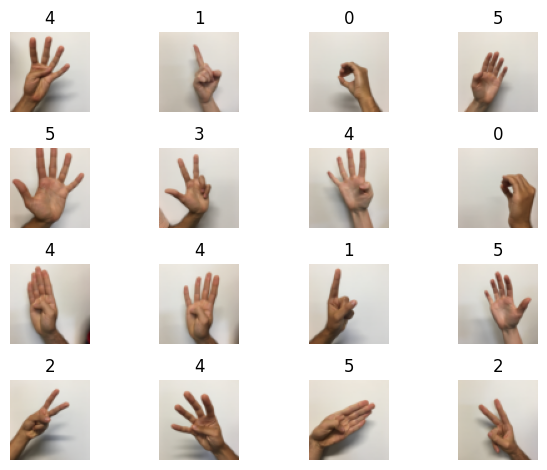

In [ ]:
plt.figure()

predicted = clf.predict(X_test_scaled)

display_samples_in_grid(X_test, n_rows=4, y= predicted)


In [ ]:
#plt.gcf().canvas.set_window_title('Test set prediction')

### Compare with SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
clf = SVC(C=10, kernel='rbf', gamma=0.001).fit(X_train_scaled, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test_scaled, y_test)))

train accuracy= 99.907%
test accuracy= 95.833%
